1. Data loaded successfully....!!!


/tmp/ipykernel_8222/4271257882.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn", data=df, palette="viridis")


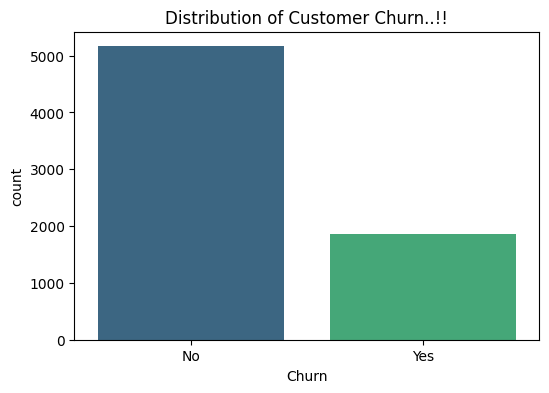


2. Model Training Completed..!!
Accuracy: 0.78

Classification Report:
               precision    recall  f1-score   support

          No       0.83      0.90      0.86      1033
         Yes       0.62      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.72      0.69      0.70      1407
weighted avg       0.77      0.78      0.77      1407



/tmp/ipykernel_8222/4271257882.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y='Feature', data=feature_importances, palette='magma')


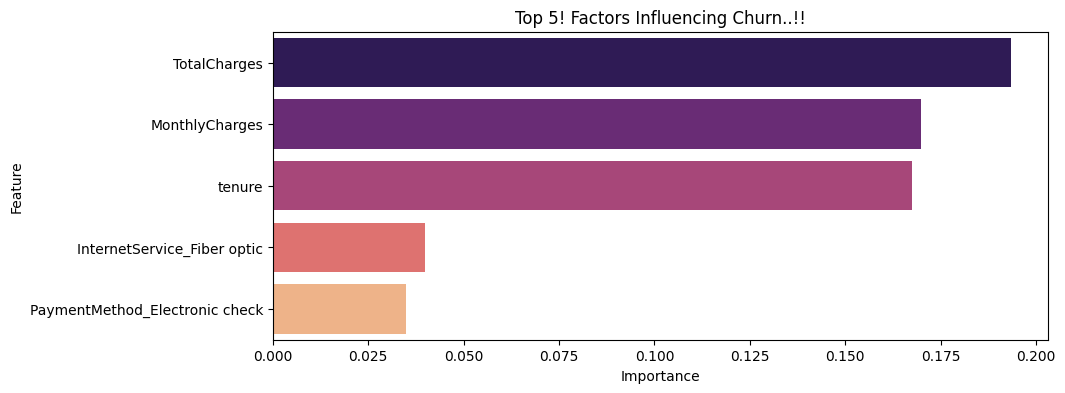


Model saved as 'churn_classifier.pkl'


In [2]:
import pandas as pdZ
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

df = pd.read_csv('telecom customer data.csv.csv')
print("1. Data loaded successfully....!!!")

if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])

if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, palette="viridis")
plt.title('Distribution of Customer Churn..!!')
plt.show()
X = df.drop(columns=['Churn'])
y = df['Churn']
X = pd.get_dummies(X, drop_first=True)

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
num_cols = [col for col in num_cols if col in X.columns]
if num_cols:
    scaler = StandardScaler()
    X[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f"\n2. Model Training Completed..!!")
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}\n')
print("Classification Report:\n", classification_report(y_test, y_pred))

importances = model.feature_importances_
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False).head(5)

plt.figure(figsize=(10,4))
sns.barplot(x="Importance", y='Feature', data=feature_importances, palette='magma')
plt.title("Top 5! Factors Influencing Churn..!!")
plt.show()

with open("churn_classifier.pkl", "wb") as file:
    pickle.dump(model, file)
print("\nModel saved as 'churn_classifier.pkl'")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')